# Tree Segmentation Validation — `ovgu_bbox` @ 250 m

Four quantitative analyses comparing the pipeline output against the Baumkataster (BK):

1. **Crown area** — segmented crown areas vs BK crown areas
2. **Tree heights** — global allometric vs tile-dominant-genus vs BK measured
3. **Match distance & count** — the 15 m threshold, and how the match rate responds to it
4. **Watershed** — for a circle of radius R around each BK tree, how many trees fall inside in the pre-split, post-split and BK sets

In [1]:
import sys, math
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Circle
from scipy.spatial import cKDTree
from shapely.geometry import box as shapely_box
from pyproj import Transformer

sys.path.insert(0, "..")
from src.config import (AREAS, ALLOMETRIC_PROFILES, ALLOMETRIC_A, ALLOMETRIC_B,
                        CROWN_RADIUS_BY_GENUS, MAX_CROWN_RADIUS_M,
                        BAUMKATASTER_PATH, OUTPUT_DIR)
from src.data_preprocessing import tiles_for_area
from src.shadow.casting import vectorize_trees
from src.shadow.cadastre import tile_dominant_genus

## The datasets

### Dataset 1 - Post-enrichment output (segmentation + the BK join)

### Dataset 2 - Baumkataster (ground truth)

In [2]:
# Dataset 1

TILE_SIZE_VAL = 250   # change to 100 / 500 / 1000 to analyse a different tile size

merged_trees = gpd.read_file(
    OUTPUT_DIR / "segments" / f"{TILE_SIZE_VAL}m" / f"ovgu_bbox_tcd_segformer_trees_merged.fgb"
)
print(f"{len(merged_trees)} polygons \n columns: {list(merged_trees.columns)}\n")
print(f"height_source breakdown:\n{merged_trees['height_source'].value_counts().to_string()}\n")
merged_trees.head(5)

942 polygons 
 columns: ['tree_id', 'height_m', 'allometric_height_m', 'crown_radius_m', 'crown_area_m2', 'vegetation_model', 'species', 'height_source', 'is_deciduous', 'trunk_circumference_cm', 'planting_year', 'bk_match_dist_m', 'h_global_m', 'geometry']

height_source breakdown:
height_source
allometric    668
measured      274



,tree_id,height_m,allometric_height_m,crown_radius_m,crown_area_m2,vegetation_model,species,height_source,is_deciduous,trunk_circumference_cm,planting_year,bk_match_dist_m,h_global_m,geometry
0,41,8.000000,8.039095,2.000000,13.455953,tcd_segformer,"Tilia cordata, Winterlinde",measured,True,70.0,None,0.5204198973191211,8.530228,"POLYGON ((681495.593 5779639.914, 681495.593 5..."
1,42,5.000000,4.188912,1.500000,2.490225,tcd_segformer,"Tilia cordata, Winterlinde",measured,True,62.0,None,0.8630782728577719,4.988497,"POLYGON ((681487.041 5779639.706, 681487.041 5..."
2,40,18.000000,17.972378,8.000000,140.173461,tcd_segformer,"Populus simonii, Birkenpappel",measured,True,190.0,None,0.9990817276521374,17.972378,"POLYGON ((681403.968 5779652.206, 681403.968 5..."
3,39,11.873385,11.873385,3.390224,36.108264,tcd_segformer,None,allometric,None,None,None,None,11.675749,"POLYGON ((681400.129 5779670.748, 681400.129 5..."
4,38,8.000000,12.773759,3.000000,44.605611,tcd_segformer,"Tilia cordata, Winterlinde",measured,True,100.0,None,0.585974173660797,12.487390,"POLYGON ((681415.661 5779674.081, 681415.661 5..."


In [3]:
# Dataset 2

bk_all   = gpd.read_file(BAUMKATASTER_PATH).to_crs(merged_trees.crs)
print(f"{len(bk_all)} trees \n columns: {list(bk_all.columns)}\n")
bk_all.head(5)

85302 trees 
 columns: ['Gattung lang', 'Stammumfang', 'Baumhoehe', 'Kronendurchmesser', 'Pflanzjahr', 'Objektbezeichnung', 'Objektart lang', 'baumnummer', 'geometry']



,Gattung lang,Stammumfang,Baumhoehe,Kronendurchmesser,Pflanzjahr,Objektbezeichnung,Objektart lang,baumnummer,geometry
0,"Tilia euchlora, Krim-Linde",120.0,14.0,8.0,1950,Zuckerbusch,Öffentliches Grün,1 -G11901,POINT (681809.315 5778107.15)
1,"Tilia cordata, Winterlinde",150.0,17.0,9.0,1930,Zuckerbusch,Öffentliches Grün,2 -G11902,POINT (681810.886 5778102.381)
2,"Tilia cordata, Winterlinde",150.0,13.0,10.0,1930,Zuckerbusch,Öffentliches Grün,3 -G11903,POINT (681816.873 5778109.728)
3,"Tilia cordata, Winterlinde",180.0,18.0,12.0,1930,Zuckerbusch,Öffentliches Grün,5 -G11905,POINT (681824.444 5778112.177)
4,"Tilia cordata, Winterlinde",110.0,13.0,6.0,1950,Zuckerbusch,Öffentliches Grün,6 -G11906,POINT (681826.114 5778107.502)


In [4]:
AREA_KEY   = "ovgu_bbox"
TILE_SIZE  = TILE_SIZE_VAL
MODEL      = "tcd_segformer"
SEG_DIR    = OUTPUT_DIR / f"segments/{TILE_SIZE}m"
MATCH_R    = 15.0   # metres — the pipeline's match_radius_m

_to_utm = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True)

# True tile extents come from tiles_for_area, never from polygon bounds
# (polygon bounds understate the tile whenever no tree touches an edge).
tiles = tiles_for_area(AREAS[AREA_KEY], TILE_SIZE)

def tile_bbox_utm(t):
    """True (minx, miny, maxx, maxy) of a tile in EPSG:25832."""
    minx, miny = _to_utm.transform(t["west"], t["south"])
    maxx, maxy = _to_utm.transform(t["east"], t["north"])
    return minx, miny, maxx, maxy

def seg_path(t):
    return SEG_DIR / f"{AREA_KEY}_tile_{t['ix']}_{t['iy']}_{MODEL}_seg.npy"

# --- Dataset 1, ready for analysis ---
# FlatGeobuf round-trips these columns as strings — coerce before any arithmetic.
merged = merged_trees.copy()
for c in ["bk_match_dist_m", "trunk_circumference_cm", "planting_year"]:
    merged[c] = pd.to_numeric(merged[c], errors="coerce")
merged["genus"] = merged["species"].str.split(",").str[0].str.strip()
matched_mask = merged["height_source"] == "measured"

# --- Dataset 2, clipped to the same extent and filtered as the pipeline filters it ---
b        = merged.total_bounds
bk_area  = bk_all.cx[b[0]:b[2], b[1]:b[3]]
bk_valid = bk_area[(bk_area["Baumhoehe"] > 1) & (bk_area["Kronendurchmesser"] > 0.5)].copy()
bk_valid["bk_crown_area_m2"] = np.pi * (bk_valid["Kronendurchmesser"] / 2) ** 2
bk_valid["genus"] = bk_valid["Gattung lang"].str.split(",").str[0].str.strip()

print(f"Area {AREA_KEY} @ {TILE_SIZE} m — {len(tiles)} tiles")
print(f"  Dataset 1  enriched segmentation : {len(merged):,} polygons")
print(f"  Dataset 2  Baumkataster in bbox  : {len(bk_valid):,} valid trees "
      f"(of {len(bk_area):,} in bbox, {len(bk_all):,} citywide)")

# h_global_m must be present on every polygon: it depends only on crown_area_m2,
# never on a BK match. Guard against regressing the cadastre.py early-return bug.
assert merged["h_global_m"].notna().all(), (
    f"{merged['h_global_m'].isna().sum()} polygons missing h_global_m — "
    "enrich_from_baumkataster must set it before its early returns"
)

Area ovgu_bbox @ 250 m — 16 tiles
  Dataset 1  enriched segmentation : 942 polygons
  Dataset 2  Baumkataster in bbox  : 1,045 valid trees (of 1,060 in bbox, 85,302 citywide)


### Basic analysis of the two datasets

Descriptive statistics before any validation is attempted.

One caveat drives how the tables below are split. The enrichment step **overwrites** `height_m` and
`crown_radius_m` on matched rows with the BK values (`Baumhoehe`, `Kronendurchmesser/2`). So in
Dataset 1:

| Column | Matched rows (274) | Unmatched rows (668) |
|---|---|---|
| `crown_area_m2` | pipeline (pixel count) | pipeline (pixel count) |
| `h_global_m` | pipeline (global allometric) | pipeline (global allometric) |
| `height_m` | **BK measured** | pipeline (allometric) |
| `crown_radius_m` | **BK, `Kronendurchmesser/2`** | pipeline, `sqrt(area/π)` |

Only `crown_area_m2` and `h_global_m` are pipeline-native throughout, so those are the columns to
read as "what the pipeline produced". `height_m` and `crown_radius_m` are reported split by source.

In [5]:
def describe(s, name):
    s = pd.Series(s).dropna()
    return {"variable": name, "n": len(s), "mean": s.mean(), "std": s.std(),
            "min": s.min(), "p25": s.quantile(.25), "median": s.median(),
            "p75": s.quantile(.75), "max": s.max()}

fmt = lambda v: f"{v:,.2f}"

# --- Dataset 1 ---
print("=" * 78)
print(f"DATASET 1 · Enriched segmentation — {len(merged):,} polygons")
print("=" * 78)
print("\nProvenance")
for src, n in merged["height_source"].value_counts().items():
    tag = "BK measured" if src == "measured" else "allometric estimate"
    print(f"  {src:12s} {n:5,d}  ({n/len(merged)*100:5.1f}%)   {tag}")

print("\nPipeline-native measurements (all polygons)")
print(pd.DataFrame([
    describe(merged["crown_area_m2"], "crown_area_m2"),
    describe(merged["h_global_m"],    "h_global_m"),
]).to_string(index=False, float_format=fmt))

print("\nColumns overwritten by enrichment — split by source")
print(pd.DataFrame([
    describe(merged.loc[matched_mask,  "height_m"],       "height_m [measured]"),
    describe(merged.loc[~matched_mask, "height_m"],       "height_m [allometric]"),
    describe(merged.loc[matched_mask,  "crown_radius_m"], "crown_radius_m [BK]"),
    describe(merged.loc[~matched_mask, "crown_radius_m"], "crown_radius_m [pipeline]"),
]).to_string(index=False, float_format=fmt))

n_blob = int((merged["crown_area_m2"] > 200).sum())
print(f"\nCrown-size structure")
print(f"  polygons > 200 m² (above a plausible single crown)   {n_blob:4d}  ({n_blob/len(merged)*100:.1f}%)")
print(f"  they hold {merged.loc[merged['crown_area_m2']>200,'crown_area_m2'].sum()/merged['crown_area_m2'].sum()*100:.1f}% of all segmented canopy area")
print(f"  distinct genera assigned by the BK join              {merged['genus'].nunique():4d}")

# --- Dataset 2 ---
print("\n" + "=" * 78)
print(f"DATASET 2 · Baumkataster — {len(bk_valid):,} valid trees in bbox")
print("=" * 78)
print(f"\nRecord counts")
print(f"  citywide                       {len(bk_all):7,d}")
print(f"  within {AREA_KEY} bbox         {len(bk_area):7,d}")
print(f"  valid (Hoehe>1, Krone>0.5)     {len(bk_valid):7,d}   "
      f"({len(bk_area)-len(bk_valid)} dropped)")

print("\nMeasurements")
print(pd.DataFrame([
    describe(bk_valid["Baumhoehe"],         "Baumhoehe (m)"),
    describe(bk_valid["Kronendurchmesser"], "Kronendurchmesser (m)"),
    describe(bk_valid["bk_crown_area_m2"],  "crown area (m², derived)"),
    describe(bk_valid["Stammumfang"],       "Stammumfang (cm)"),
]).to_string(index=False, float_format=fmt))

print("\nMeasurement granularity (the BK is recorded in coarse steps)")
for c in ["Baumhoehe", "Kronendurchmesser"]:
    u = np.sort(bk_valid[c].unique())
    print(f"  {c:20s} {len(u):3d} distinct values, e.g. {list(u[:8])}")

print(f"\nSite type (Objektart lang)")
for k, v in bk_valid["Objektart lang"].value_counts().head(4).items():
    print(f"  {str(k)[:44]:44s} {v:5,d}  ({v/len(bk_valid)*100:5.1f}%)")

# --- Side by side on the shared quantities ---
print("\n" + "=" * 78)
print("SHARED QUANTITIES · Dataset 1 vs Dataset 2")
print("=" * 78)
print(pd.DataFrame([
    describe(merged["crown_area_m2"],       "crown area — D1 pipeline (all)"),
    describe(bk_valid["bk_crown_area_m2"],  "crown area — D2 BK (all)"),
    describe(merged["h_global_m"],          "height — D1 global allometric (all)"),
    describe(bk_valid["Baumhoehe"],         "height — D2 BK measured (all)"),
]).to_string(index=False, float_format=fmt))
print("\nNote: these are whole-population comparisons, not per-tree pairs — the two sets")
print("cover the same ground but are not one-to-one. Paired comparison follows in section 1.")

DATASET 1 · Enriched segmentation — 942 polygons

Provenance
  allometric     668  ( 70.9%)   allometric estimate
  measured       274  ( 29.1%)   BK measured

Pipeline-native measurements (all polygons)
     variable   n   mean    std  min   p25  median    p75      max
crown_area_m2 942 170.42 451.91 1.38 20.44   44.88 141.41 4,850.22
   h_global_m 942  14.68   7.72 4.13  9.74   12.51  18.02    55.47

Columns overwritten by enrichment — split by source
                 variable   n  mean  std  min  p25  median   p75   max
      height_m [measured] 274 11.70 5.55 3.00 8.00   10.00 15.00 28.00
    height_m [allometric] 668 14.12 6.94 4.00 9.17   12.62 17.93 51.38
      crown_radius_m [BK] 274  4.06 2.07 0.50 3.00    3.50  5.00 13.00
crown_radius_m [pipeline] 668  4.88 3.76 0.70 2.48    3.78  6.41 32.17

Crown-size structure
  polygons > 200 m² (above a plausible single crown)    167  (17.7%)
  they hold 74.3% of all segmented canopy area
  distinct genera assigned by the BK join        

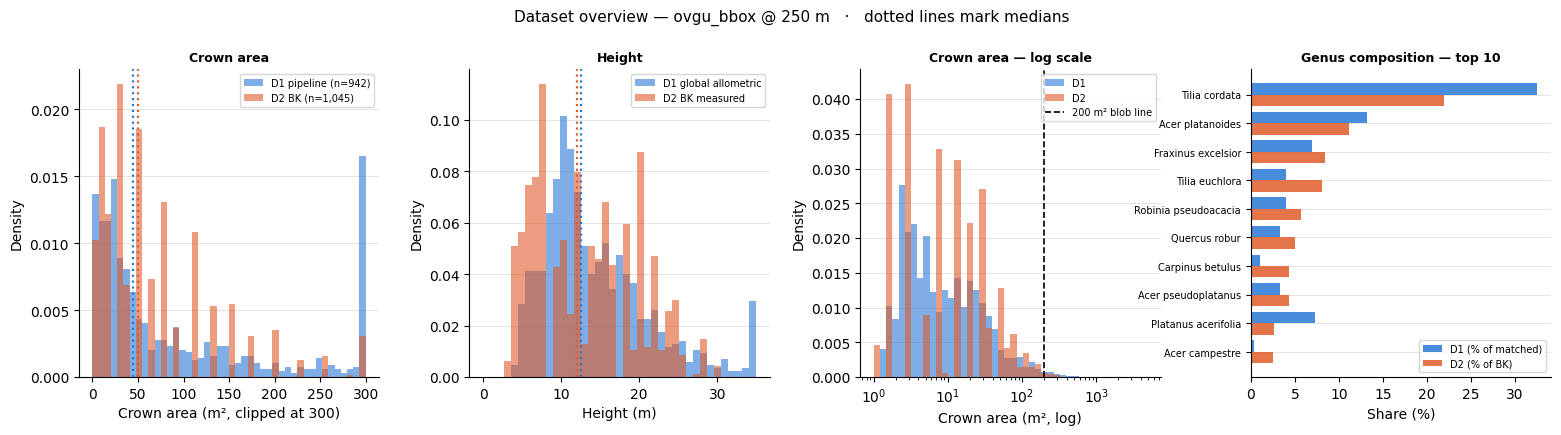

In [6]:
C1, C2 = "#2a78d6", "#e05c2a"   # D1 pipeline, D2 Baumkataster

fig, axes = plt.subplots(1, 4, figsize=(19, 4), gridspec_kw={"wspace": 0.30})

# Panel 1 — crown area
bins = np.linspace(0, 300, 45)
axes[0].hist(merged["crown_area_m2"].clip(0, 300), bins=bins, density=True,
             alpha=0.6, color=C1, label=f"D1 pipeline (n={len(merged):,})")
axes[0].hist(bk_valid["bk_crown_area_m2"].clip(0, 300), bins=bins, density=True,
             alpha=0.6, color=C2, label=f"D2 BK (n={len(bk_valid):,})")
for v, c in [(merged["crown_area_m2"].median(), C1), (bk_valid["bk_crown_area_m2"].median(), C2)]:
    axes[0].axvline(v, color=c, linewidth=1.6, linestyle=":")
axes[0].set_xlabel("Crown area (m², clipped at 300)"); axes[0].set_ylabel("Density")
axes[0].set_title("Crown area", fontsize=9, fontweight="bold"); axes[0].legend(fontsize=7)

# Panel 2 — height
bins = np.linspace(0, 35, 40)
axes[1].hist(merged["h_global_m"].clip(0, 35), bins=bins, density=True,
             alpha=0.6, color=C1, label="D1 global allometric")
axes[1].hist(bk_valid["Baumhoehe"].clip(0, 35), bins=bins, density=True,
             alpha=0.6, color=C2, label="D2 BK measured")
for v, c in [(merged["h_global_m"].median(), C1), (bk_valid["Baumhoehe"].median(), C2)]:
    axes[1].axvline(v, color=c, linewidth=1.6, linestyle=":")
axes[1].set_xlabel("Height (m)"); axes[1].set_ylabel("Density")
axes[1].set_title("Height", fontsize=9, fontweight="bold"); axes[1].legend(fontsize=7)

# Panel 3 — crown area on a log axis, where the blob tail is visible
logbins = np.logspace(np.log10(1), np.log10(max(merged["crown_area_m2"].max(),
                                                bk_valid["bk_crown_area_m2"].max())), 45)
axes[2].hist(merged["crown_area_m2"], bins=logbins, density=True, alpha=0.6, color=C1, label="D1")
axes[2].hist(bk_valid["bk_crown_area_m2"], bins=logbins, density=True, alpha=0.6, color=C2, label="D2")
axes[2].axvline(200, color="black", linestyle="--", linewidth=1.2, label="200 m² blob line")
axes[2].set_xscale("log")
axes[2].set_xlabel("Crown area (m², log)"); axes[2].set_ylabel("Density")
axes[2].set_title("Crown area — log scale", fontsize=9, fontweight="bold"); axes[2].legend(fontsize=7)

# Panel 4 — genus composition, top 10 by BK count
top_genera = bk_valid["genus"].value_counts().head(10).index[::-1]
y = np.arange(len(top_genera)); h = 0.4
d1_share = [(merged["genus"] == g).sum() / matched_mask.sum() * 100 for g in top_genera]
d2_share = [(bk_valid["genus"] == g).sum() / len(bk_valid) * 100 for g in top_genera]
axes[3].barh(y + h/2, d1_share, h, color=C1, alpha=0.85, label="D1 (% of matched)")
axes[3].barh(y - h/2, d2_share, h, color=C2, alpha=0.85, label="D2 (% of BK)")
axes[3].set_yticks(y); axes[3].set_yticklabels(top_genera, fontsize=7)
axes[3].set_xlabel("Share (%)")
axes[3].set_title("Genus composition — top 10", fontsize=9, fontweight="bold")
axes[3].legend(fontsize=7)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.6); ax.set_axisbelow(True)

fig.suptitle(
    f"Dataset overview — {AREA_KEY} @ {TILE_SIZE} m   ·   dotted lines mark medians",
    fontsize=11, y=1.03,
)
plt.show()

## 1 · Crown area comparison

For matched trees the BK crown radius is already stored in `crown_radius_m` (the enrichment step
overwrites it with `Kronendurchmesser/2`), so the BK crown area is exactly `π · crown_radius_m²` —
no re-matching needed. `crown_area_m2` remains the pipeline's own pixel-derived area.

In [7]:
matched = merged[matched_mask].dropna(subset=["crown_area_m2", "crown_radius_m"]).copy()
# BK crown area straight from the pipeline's own match (see markdown above)
matched["bk_crown_area_m2"] = np.pi * matched["crown_radius_m"] ** 2
ratio = matched["crown_area_m2"] / matched["bk_crown_area_m2"]

print(f"Matched trees:              {len(matched):,}")
print(f"Pipeline CPA median:        {merged['crown_area_m2'].median():.1f} m²")
print(f"BK CPA median (all BK):     {bk_valid['bk_crown_area_m2'].median():.1f} m²")
print(f"BK CPA median (matched):    {matched['bk_crown_area_m2'].median():.1f} m²")
print(f"Ratio  median {ratio.median():.2f}   mean {ratio.mean():.2f}   std {ratio.std():.2f}")
print(f"Trees with ratio > 2:       {(ratio > 2).sum()} ({(ratio > 2).mean()*100:.1f}%)")

Matched trees:              274
Pipeline CPA median:        44.9 m²
BK CPA median (all BK):     50.3 m²
BK CPA median (matched):    38.5 m²
Ratio  median 1.15   mean 45.18   std 420.12
Trees with ratio > 2:       73 (26.6%)


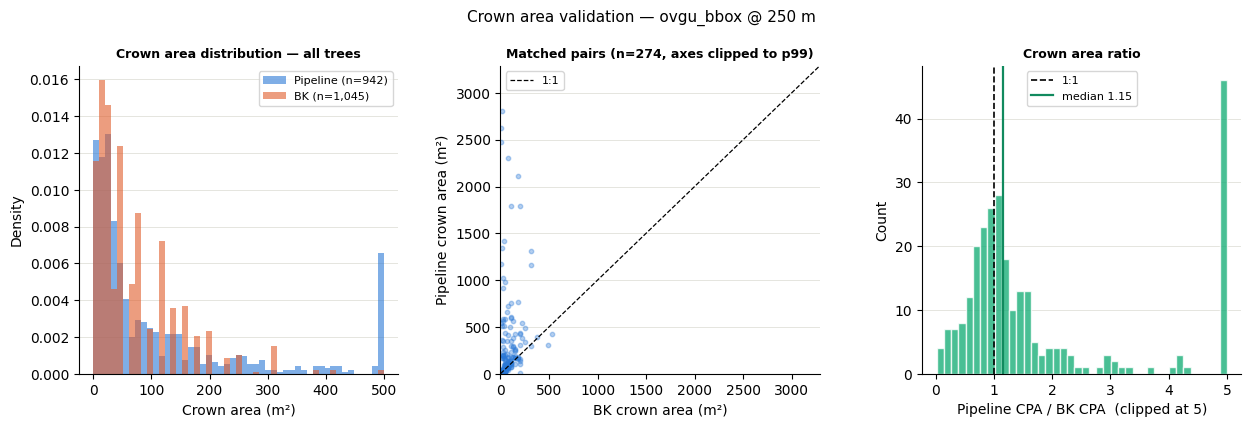

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), gridspec_kw={"wspace": 0.32})

# Panel 1 — overall crown-area distributions
bins = np.linspace(0, 500, 50)
axes[0].hist(merged["crown_area_m2"].clip(0, 500), bins=bins, density=True,
             alpha=0.6, color="#2a78d6", label=f"Pipeline (n={len(merged):,})")
axes[0].hist(bk_valid["bk_crown_area_m2"].clip(0, 500), bins=bins, density=True,
             alpha=0.6, color="#e05c2a", label=f"BK (n={len(bk_valid):,})")
axes[0].set_xlabel("Crown area (m²)"); axes[0].set_ylabel("Density")
axes[0].set_title("Crown area distribution — all trees", fontsize=9, fontweight="bold")
axes[0].legend(fontsize=8)

# Panel 2 — matched-pair scatter
lim = float(np.nanpercentile(
    np.concatenate([matched["bk_crown_area_m2"], matched["crown_area_m2"]]), 99))
axes[1].scatter(matched["bk_crown_area_m2"], matched["crown_area_m2"],
                alpha=0.35, s=10, color="#2a78d6")
axes[1].plot([0, lim], [0, lim], "k--", linewidth=0.9, label="1:1")
axes[1].set_xlim(0, lim); axes[1].set_ylim(0, lim)
axes[1].set_xlabel("BK crown area (m²)"); axes[1].set_ylabel("Pipeline crown area (m²)")
axes[1].set_title(f"Matched pairs (n={len(matched):,}, axes clipped to p99)",
                  fontsize=9, fontweight="bold")
axes[1].legend(fontsize=8)

# Panel 3 — ratio histogram
axes[2].hist(ratio.clip(0, 5), bins=40, color="#1baf7a", alpha=0.8, edgecolor="white")
axes[2].axvline(1.0, color="black", linestyle="--", linewidth=1.2, label="1:1")
axes[2].axvline(ratio.median(), color="#118a5e", linewidth=1.6,
                label=f"median {ratio.median():.2f}")
axes[2].set_xlabel("Pipeline CPA / BK CPA  (clipped at 5)"); axes[2].set_ylabel("Count")
axes[2].set_title("Crown area ratio", fontsize=9, fontweight="bold")
axes[2].legend(fontsize=8)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.6); ax.set_axisbelow(True)

fig.suptitle(f"Crown area validation — {AREA_KEY} @ {TILE_SIZE} m", fontsize=11, y=1.02)
plt.show()

## 2 · Height comparison: global vs tile-dominant genus vs BK

Three predictions are compared against the BK measured height on matched trees:

| Model | (A, B) source |
|---|---|
| **Global** | `ALLOMETRIC_A/B` = (1.317, 0.318), same for every tree |
| **Tile-dominant** | the modal BK genus in the tile, via `tile_dominant_genus()` |
| **Per-species** | each tree's own BK species (already in `allometric_height_m`) |

The tile-dominant lookup must use `tile_dominant_genus()`, which strips the German name after the
comma — `ALLOMETRIC_PROFILES` is keyed on the bare binomial, so a raw `Gattung lang` value would
never match and would silently collapse onto the global model.

In [9]:
# Tile-dominant genus per tile, using the true tile extent and the pipeline's own helper
tile_geom, tile_genus = {}, {}
for t in tiles:
    key   = (t["ix"], t["iy"])
    bbox  = tile_bbox_utm(t)
    tile_geom[key] = bbox
    bk_tile = bk_valid.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]
    tile_genus[key] = tile_dominant_genus(bk_tile) if len(bk_tile) else None

def assign_tile(geom):
    cx, cy = geom.centroid.x, geom.centroid.y
    for key, (minx, miny, maxx, maxy) in tile_geom.items():
        if minx <= cx <= maxx and miny <= cy <= maxy:
            return key
    return None

matched2 = merged[matched_mask].dropna(
    subset=["height_m", "h_global_m", "allometric_height_m", "crown_area_m2"]
).copy()
matched2 = matched2[matched2["height_m"] > 1]
matched2["tile"] = matched2["geometry"].apply(assign_tile)

def dominant_height(row):
    genus = tile_genus.get(row["tile"])
    A, B = ALLOMETRIC_PROFILES.get(genus, (ALLOMETRIC_A, ALLOMETRIC_B))
    return math.exp(A + B * math.log(max(row["crown_area_m2"], 1e-6)))

matched2["h_tile_dominant_m"] = matched2.apply(dominant_height, axis=1)

print("Tile-dominant genus per tile:")
for key in sorted(tile_genus):
    g = tile_genus[key]
    hit = "profile" if g in ALLOMETRIC_PROFILES else "global fallback"
    print(f"  {str(key):8s} {str(g):32s} [{hit}]")

print(f"\nMatched trees for height analysis: {len(matched2):,}\n")
print(f"  {'Model':16s} {'mean':>9s} {'median':>9s} {'std':>9s} {'|dev|>20%':>10s}")
for col, label in [("h_global_m", "Global"),
                   ("h_tile_dominant_m", "Tile-dominant"),
                   ("allometric_height_m", "Per-species")]:
    dev = (matched2[col] - matched2["height_m"]) / matched2["height_m"] * 100
    print(f"  {label:16s} {dev.mean():+8.1f}% {dev.median():+8.1f}% {dev.std():8.1f}% "
          f"{(dev.abs() > 20).mean()*100:9.1f}%")

Tile-dominant genus per tile:
  (0, 0)   Platanus acerifolia              [profile]
  (0, 1)   Tilia euchlora                   [profile]
  (0, 2)   Quercus robur                    [profile]
  (0, 3)   Populus simonii                  [global fallback]
  (1, 0)   Tilia cordata                    [profile]
  (1, 1)   Tilia euchlora                   [profile]
  (1, 2)   Tilia cordata                    [profile]
  (1, 3)   Quercus robur                    [profile]
  (2, 0)   Tilia cordata                    [profile]
  (2, 1)   Sorbus intermedia                [profile]
  (2, 2)   Robinia pseudoacacia             [profile]
  (2, 3)   None                             [global fallback]
  (3, 0)   Acer platanoides                 [profile]
  (3, 1)   Sorbus thuringiaca 'Fastigiata'  [global fallback]
  (3, 2)   Amelanchier lamarckii            [global fallback]
  (3, 3)   None                             [global fallback]

Matched trees for height analysis: 274

  Model                 m

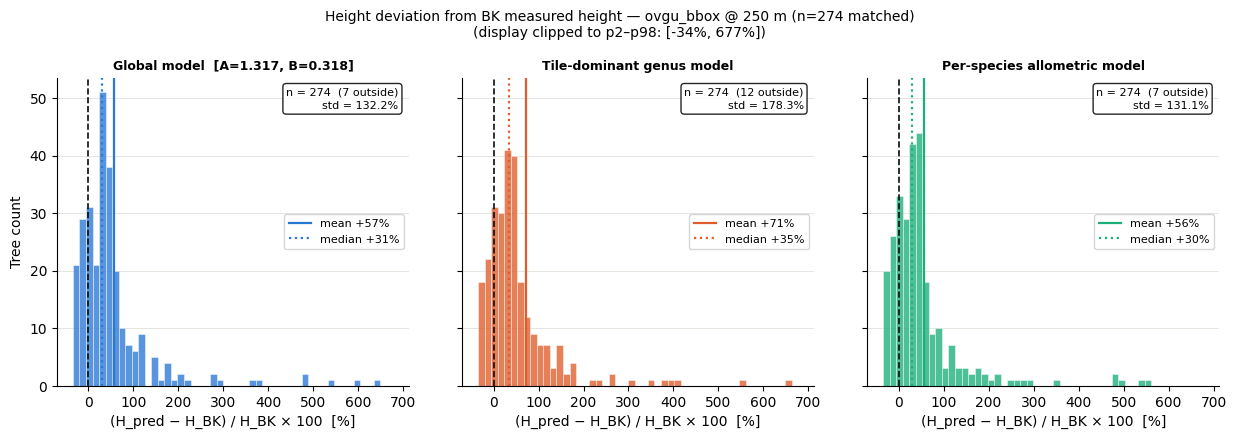

In [10]:
pairs = [
    ("h_global_m",          f"Global model  [A={ALLOMETRIC_A}, B={ALLOMETRIC_B}]", "#2a78d6"),
    ("h_tile_dominant_m",   "Tile-dominant genus model",                           "#e05c2a"),
    ("allometric_height_m", "Per-species allometric model",                        "#1baf7a"),
]
devs = {c: (matched2[c] - matched2["height_m"]) / matched2["height_m"] * 100 for c, *_ in pairs}
lo   = min(np.percentile(d, 2)  for d in devs.values())
hi   = max(np.percentile(d, 98) for d in devs.values())
bins = np.linspace(lo, hi, 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True, gridspec_kw={"wspace": 0.15})
for ax, (col, label, color) in zip(axes, pairs):
    dev = devs[col]
    ax.hist(dev, bins=bins, color=color, alpha=0.78, edgecolor="white", linewidth=0.4)
    ax.axvline(0, color="#0b0b0b", linewidth=1.2, linestyle="--")
    ax.axvline(dev.mean(),   color=color, linewidth=1.6, linestyle="-", label=f"mean {dev.mean():+.0f}%")
    ax.axvline(dev.median(), color=color, linewidth=1.6, linestyle=":", label=f"median {dev.median():+.0f}%")
    n_out = int(((dev < lo) | (dev > hi)).sum())
    ax.set_title(label, fontsize=9, fontweight="bold")
    ax.set_xlabel("(H_pred − H_BK) / H_BK × 100  [%]")
    ax.legend(fontsize=8)
    ax.text(0.97, 0.97, f"n = {len(dev):,}  ({n_out} outside)\nstd = {dev.std():.1f}%",
            transform=ax.transAxes, va="top", ha="right", fontsize=8, linespacing=1.5,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85))
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.6); ax.set_axisbelow(True)
axes[0].set_ylabel("Tree count")

fig.suptitle(
    f"Height deviation from BK measured height — {AREA_KEY} @ {TILE_SIZE} m "
    f"(n={len(matched2):,} matched)\n(display clipped to p2–p98: [{lo:.0f}%, {hi:.0f}%])",
    fontsize=10, y=1.05,
)
plt.show()

## 3 · Match distance & threshold optimisation

Two distinct quantities:

- `bk_match_dist_m` — the distance the pipeline actually recorded, for trees it matched (≤ 15 m by construction)
- **nearest-BK distance** — recomputed here by KD-tree for *every* polygon including unmatched ones, which is what the threshold sweep needs

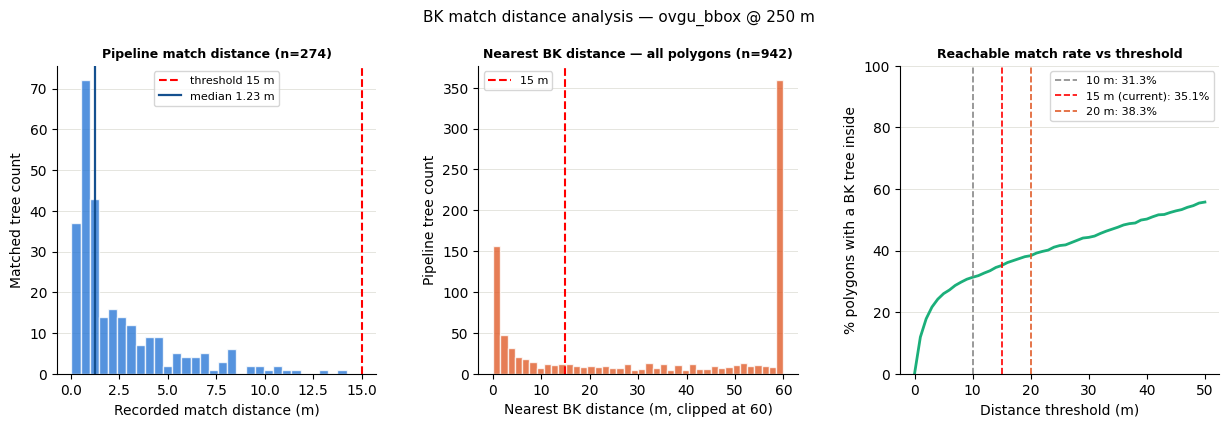

Actual pipeline match rate: 29.1%  (274/942)

Upper bound if the threshold alone were relaxed:
  ≤ 5 m:  245 polygons  ( 26.0%)
  ≤10 m:  295 polygons  ( 31.3%)
  ≤15 m:  331 polygons  ( 35.1%)
  ≤20 m:  361 polygons  ( 38.3%)
  ≤25 m:  392 polygons  ( 41.6%)


In [11]:
matched_dist = merged["bk_match_dist_m"].dropna()   # numeric — coerced in the setup cell

seg_centroids = np.array([[g.centroid.x, g.centroid.y] for g in merged.geometry])
bk_coords     = np.array([[g.x, g.y] for g in bk_valid.geometry])
nn_dists, _   = cKDTree(bk_coords).query(seg_centroids, k=1)

thresholds = np.arange(0, 51, 1)
cumulative = [(nn_dists <= t).mean() * 100 for t in thresholds]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), gridspec_kw={"wspace": 0.32})

axes[0].hist(matched_dist, bins=30, color="#2a78d6", alpha=0.8, edgecolor="white")
axes[0].axvline(MATCH_R, color="red", linestyle="--", linewidth=1.5, label=f"threshold {MATCH_R:.0f} m")
axes[0].axvline(matched_dist.median(), color="#14508f", linewidth=1.6,
                label=f"median {matched_dist.median():.2f} m")
axes[0].set_xlabel("Recorded match distance (m)"); axes[0].set_ylabel("Matched tree count")
axes[0].set_title(f"Pipeline match distance (n={len(matched_dist):,})", fontsize=9, fontweight="bold")
axes[0].legend(fontsize=8)

axes[1].hist(nn_dists.clip(0, 60), bins=40, color="#e05c2a", alpha=0.8, edgecolor="white")
axes[1].axvline(MATCH_R, color="red", linestyle="--", linewidth=1.5, label=f"{MATCH_R:.0f} m")
axes[1].set_xlabel("Nearest BK distance (m, clipped at 60)"); axes[1].set_ylabel("Pipeline tree count")
axes[1].set_title(f"Nearest BK distance — all polygons (n={len(nn_dists):,})",
                  fontsize=9, fontweight="bold")
axes[1].legend(fontsize=8)

axes[2].plot(thresholds, cumulative, color="#1baf7a", linewidth=2)
for t, color, lbl in [(10, "#888888", "10 m"), (15, "red", "15 m (current)"), (20, "#e05c2a", "20 m")]:
    axes[2].axvline(t, color=color, linestyle="--", linewidth=1.2,
                    label=f"{lbl}: {(nn_dists <= t).mean()*100:.1f}%")
axes[2].set_xlabel("Distance threshold (m)"); axes[2].set_ylabel("% polygons with a BK tree inside")
axes[2].set_title("Reachable match rate vs threshold", fontsize=9, fontweight="bold")
axes[2].set_ylim(0, 100); axes[2].legend(fontsize=8)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.6); ax.set_axisbelow(True)

fig.suptitle(f"BK match distance analysis — {AREA_KEY} @ {TILE_SIZE} m", fontsize=11, y=1.02)
plt.show()

print(f"Actual pipeline match rate: {matched_mask.mean()*100:.1f}%  ({matched_mask.sum():,}/{len(merged):,})")
print(f"\nUpper bound if the threshold alone were relaxed:")
for t in [5, 10, 15, 20, 25]:
    n = int((nn_dists <= t).sum())
    print(f"  ≤{t:2d} m: {n:4d} polygons  ({n/len(nn_dists)*100:5.1f}%)")

## 4 · Watershed: trees inside the match circle (pre-split / post-split / BK)

Because the stored FGBs are not watershed-split, both sets are recomputed here from the tile's
`.npy` using `vectorize_trees` — once with `apply_watershed=False` and once with `True`, using the
same per-genus radius the pipeline would use (`CROWN_RADIUS_BY_GENUS`, falling back to
`MAX_CROWN_RADIUS_M`). Both GeoDataFrames are correctly georeferenced by `vectorize_trees` itself.

For each BK tree in the tile we then draw a circle of radius R and count how many trees fall inside,
in each of the three sets. **The ideal is exactly 1** — one segmented crown per registered tree.

In [12]:
def tile_split_sets(t):
    """Return (pre_gdf, post_gdf, bk_in_tile, genus, max_r) for one tile."""
    seg  = np.load(seg_path(t))
    mask = (seg == 1)
    minx, miny, maxx, maxy = tile_bbox_utm(t)
    bk_in = bk_valid.cx[minx:maxx, miny:maxy].copy()

    # Same genus/radius selection as pipeline.py:1134-1136
    bk_clip = bk_all.clip(gpd.GeoDataFrame(
        geometry=[shapely_box(minx, miny, maxx, maxy)], crs="EPSG:25832"))
    genus = tile_dominant_genus(bk_clip) if len(bk_clip) else None
    max_r = CROWN_RADIUS_BY_GENUS.get(genus, MAX_CROWN_RADIUS_M) if genus else MAX_CROWN_RADIUS_M

    kw = dict(dominant_genus=genus, max_crown_radius_m=max_r)
    pre  = vectorize_trees(mask, t, MODEL, apply_watershed=False, **kw)
    post = vectorize_trees(mask, t, MODEL, apply_watershed=True,  **kw)
    return pre, post, bk_in, genus, max_r

# Focus tile = the one with the most BK trees
focus = max(tiles, key=lambda t: len(bk_valid.cx[tile_bbox_utm(t)[0]:tile_bbox_utm(t)[2],
                                                  tile_bbox_utm(t)[1]:tile_bbox_utm(t)[3]]))
FOCUS_IX, FOCUS_IY = focus["ix"], focus["iy"]

pre_gdf, post_gdf, bk_tile, genus, max_r = tile_split_sets(focus)
pre_xy  = np.array([[g.centroid.x, g.centroid.y] for g in pre_gdf.geometry])
post_xy = np.array([[g.centroid.x, g.centroid.y] for g in post_gdf.geometry])
bk_xy   = np.array([[g.x, g.y] for g in bk_tile.geometry])

print(f"Focus tile ({FOCUS_IX},{FOCUS_IY})   dominant genus: {genus}   split radius: {max_r} m")
print(f"  pre-watershed crowns   {len(pre_xy)}")
print(f"  post-watershed crowns  {len(post_xy)}   (+{len(post_xy) - len(pre_xy)})")
print(f"  BK trees in tile       {len(bk_xy)}")

kd_pre, kd_post, kd_bk = cKDTree(pre_xy), cKDTree(post_xy), cKDTree(bk_xy)
counts_pre  = np.array([len(kd_pre.query_ball_point(p, MATCH_R))      for p in bk_xy])
counts_post = np.array([len(kd_post.query_ball_point(p, MATCH_R))     for p in bk_xy])
counts_bk   = np.array([len(kd_bk.query_ball_point(p, MATCH_R)) - 1   for p in bk_xy])  # exclude self

print(f"\nTrees inside a {MATCH_R:.0f} m circle around each of the {len(bk_xy)} BK points:")
print(f"  {'set':16s} {'mean':>7s} {'0':>5s} {'1':>5s} {'>=2':>5s}")
for name, arr in [("Pre-watershed", counts_pre), ("Post-watershed", counts_post), ("BK neighbours", counts_bk)]:
    print(f"  {name:16s} {arr.mean():7.2f} {(arr==0).sum():5d} {(arr==1).sum():5d} {(arr>=2).sum():5d}")

Focus tile (1,2)   dominant genus: Tilia cordata   split radius: 6.5 m
  pre-watershed crowns   69
  post-watershed crowns  153   (+84)
  BK trees in tile       300

Trees inside a 15 m circle around each of the 300 BK points:
  set                 mean     0     1   >=2
  Pre-watershed       0.73   120   149    31
  Post-watershed      1.84    22   115   163
  BK neighbours       4.29    15    28   257


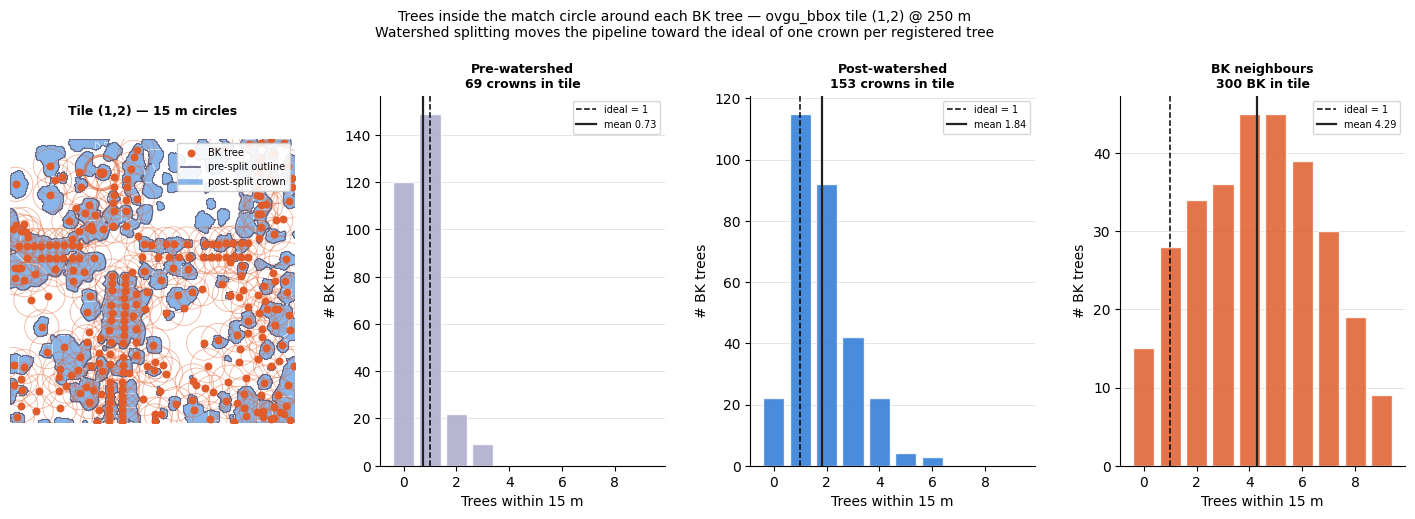

Match quality vs radius — tile (1,2), 300 BK trees

  R (m) |  pre: 0      1    >=2 |  post: 0      1    >=2
  ----------------------------------------------------------
      5 |   84.0%  16.0%   0.0% |    58.7%  41.0%   0.3%
     10 |   68.7%  29.7%   1.7% |    28.0%  57.7%  14.3%
     15 |   40.0%  49.7%  10.3% |     7.3%  38.3%  54.3%
     20 |   23.3%  47.0%  29.7% |     1.0%  14.3%  84.7%
     25 |   10.7%  37.7%  51.7% |     0.0%   3.7%  96.3%


In [13]:
fig = plt.figure(figsize=(18, 4.8))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.30)

# Panel 1 — spatial map of the focus tile
ax = fig.add_subplot(gs[0])
minx, miny, maxx, maxy = tile_bbox_utm(focus)
post_gdf.plot(ax=ax, facecolor="#2a78d6", edgecolor="white", linewidth=0.5, alpha=0.55)
pre_gdf.boundary.plot(ax=ax, edgecolor="#5b5b7a", linewidth=0.8, alpha=0.9)
ax.scatter(bk_xy[:, 0], bk_xy[:, 1], s=22, c="#e05c2a", zorder=5, label="BK tree")
for p in bk_xy:
    ax.add_patch(Circle(p, MATCH_R, fill=False, edgecolor="#e05c2a", linewidth=0.6, alpha=0.45))
ax.plot([], [], color="#5b5b7a", linewidth=1.2, label="pre-split outline")
ax.plot([], [], color="#2a78d6", linewidth=4, alpha=0.55, label="post-split crown")
ax.set_xlim(minx, maxx); ax.set_ylim(miny, maxy)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title(f"Tile ({FOCUS_IX},{FOCUS_IY}) — {MATCH_R:.0f} m circles", fontsize=9, fontweight="bold")
ax.legend(fontsize=7, loc="upper right", framealpha=0.9)

# Panels 2-4 — count histograms
hist_data = [
    (counts_pre,  f"Pre-watershed\n{len(pre_xy)} crowns in tile",  "#aaaacc"),
    (counts_post, f"Post-watershed\n{len(post_xy)} crowns in tile", "#2a78d6"),
    (counts_bk,   f"BK neighbours\n{len(bk_xy)} BK in tile",        "#e05c2a"),
]
max_c = max(int(a.max()) for a, *_ in hist_data)
for i, (arr, label, color) in enumerate(hist_data):
    ax = fig.add_subplot(gs[i + 1])
    ax.bar(np.arange(max_c + 1), np.bincount(arr, minlength=max_c + 1),
           color=color, alpha=0.85, edgecolor="white")
    ax.axvline(1.0, color="black", linewidth=1.1, linestyle="--", label="ideal = 1")
    ax.axvline(arr.mean(), color="#222222", linewidth=1.6, label=f"mean {arr.mean():.2f}")
    ax.set_xlabel(f"Trees within {MATCH_R:.0f} m"); ax.set_ylabel("# BK trees")
    ax.set_title(label, fontsize=9, fontweight="bold")
    ax.legend(fontsize=7)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.6); ax.set_axisbelow(True)

fig.suptitle(
    f"Trees inside the match circle around each BK tree — {AREA_KEY} tile ({FOCUS_IX},{FOCUS_IY}) @ {TILE_SIZE} m\n"
    "Watershed splitting moves the pipeline toward the ideal of one crown per registered tree",
    fontsize=10, y=1.06,
)
plt.show()

print(f"Match quality vs radius — tile ({FOCUS_IX},{FOCUS_IY}), {len(bk_xy)} BK trees\n")
print(f"  {'R (m)':>5} | {'pre: 0':>7} {'1':>6} {'>=2':>6} | {'post: 0':>8} {'1':>6} {'>=2':>6}")
print("  " + "-" * 58)
for R in [5, 10, 15, 20, 25]:
    cp = np.array([len(kd_pre.query_ball_point(p, R))  for p in bk_xy])
    cq = np.array([len(kd_post.query_ball_point(p, R)) for p in bk_xy])
    print(f"  {R:>5} | {(cp==0).mean()*100:6.1f}% {(cp==1).mean()*100:5.1f}% {(cp>=2).mean()*100:5.1f}% "
          f"| {(cq==0).mean()*100:7.1f}% {(cq==1).mean()*100:5.1f}% {(cq>=2).mean()*100:5.1f}%")

### Watershed effect across all tiles

 tile                           genus  max_r  n_pre  n_post  split_gain  n_bk  post_vs_bk  area_ratio
(0,0)             Platanus acerifolia  8.500     57      93          36    33       2.818       1.000
(0,1)                  Tilia euchlora  7.000     82     109          27    96       1.135       1.000
(0,2)                   Quercus robur  9.000     65      95          30   132       0.720       1.000
(0,3)                 Populus simonii  8.000     43      66          23    14       4.714       1.000
(1,0)                   Tilia cordata  6.500     82     141          59    81       1.741       1.000
(1,1)                  Tilia euchlora  7.000     93     156          63   171       0.912       1.000
(1,2)                   Tilia cordata  6.500     69     153          84   300       0.510       1.000
(1,3)                   Quercus robur  9.000     40      74          34    20       3.700       1.000
(2,0)                   Tilia cordata  6.500    105     131          26    65     

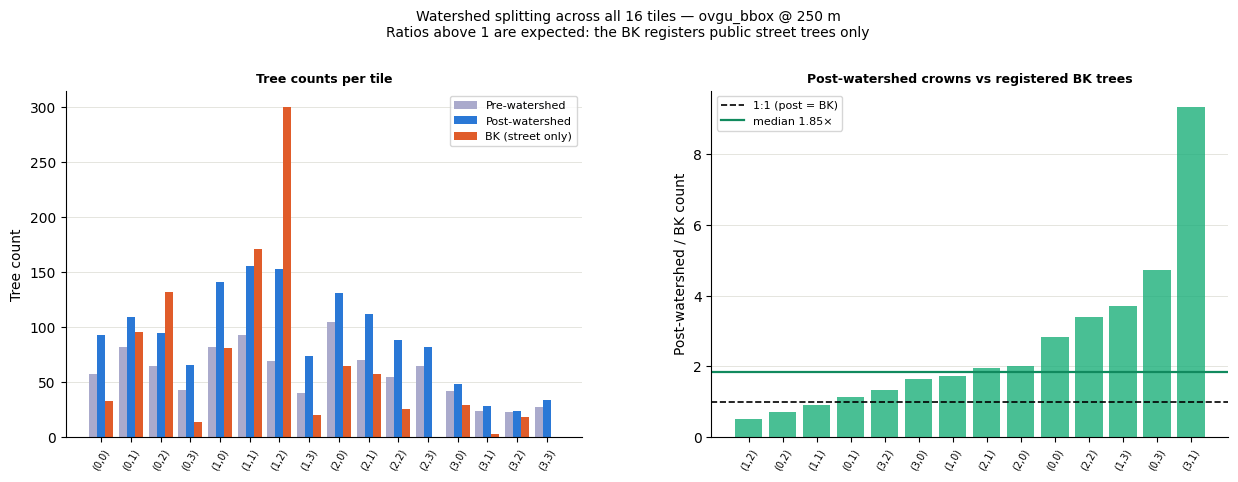

In [14]:
rows = []
for t in tiles:
    pre, post, bk_in, g, mr = tile_split_sets(t)
    rows.append({
        "tile": f"({t['ix']},{t['iy']})", "genus": g, "max_r": mr,
        "n_pre": len(pre), "n_post": len(post), "n_bk": len(bk_in),
        "area_pre": pre["crown_area_m2"].sum(), "area_post": post["crown_area_m2"].sum(),
    })
wdf = pd.DataFrame(rows)
wdf["split_gain"]   = wdf["n_post"] - wdf["n_pre"]
wdf["area_ratio"]   = wdf["area_post"] / wdf["area_pre"]
wdf["post_vs_bk"]   = wdf["n_post"] / wdf["n_bk"].replace(0, np.nan)

print(wdf[["tile", "genus", "max_r", "n_pre", "n_post", "split_gain", "n_bk", "post_vs_bk", "area_ratio"]]
      .to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print(f"\nTOTAL  pre={wdf['n_pre'].sum()}  post={wdf['n_post'].sum()}  "
      f"(+{wdf['split_gain'].sum()}, {wdf['n_post'].sum()/wdf['n_pre'].sum():.2f}×)  BK={wdf['n_bk'].sum()}")
print(f"Crown area conserved by splitting: ratio = {wdf['area_post'].sum()/wdf['area_pre'].sum():.4f}")

x = np.arange(len(wdf)); w = 0.27
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"wspace": 0.25})

axes[0].bar(x - w, wdf["n_pre"],  w, label="Pre-watershed",  color="#aaaacc")
axes[0].bar(x,     wdf["n_post"], w, label="Post-watershed", color="#2a78d6")
axes[0].bar(x + w, wdf["n_bk"],   w, label="BK (street only)", color="#e05c2a")
axes[0].set_xticks(x); axes[0].set_xticklabels(wdf["tile"], rotation=60, fontsize=7)
axes[0].set_ylabel("Tree count")
axes[0].set_title("Tree counts per tile", fontsize=9, fontweight="bold")
axes[0].legend(fontsize=8)

s = wdf.dropna(subset=["post_vs_bk"]).sort_values("post_vs_bk")
axes[1].bar(range(len(s)), s["post_vs_bk"], color="#1baf7a", alpha=0.8)
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1.2, label="1:1 (post = BK)")
axes[1].axhline(s["post_vs_bk"].median(), color="#118a5e", linewidth=1.6,
                label=f"median {s['post_vs_bk'].median():.2f}×")
axes[1].set_xticks(range(len(s))); axes[1].set_xticklabels(s["tile"], rotation=60, fontsize=7)
axes[1].set_ylabel("Post-watershed / BK count")
axes[1].set_title("Post-watershed crowns vs registered BK trees", fontsize=9, fontweight="bold")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.6); ax.set_axisbelow(True)

fig.suptitle(
    f"Watershed splitting across all {len(wdf)} tiles — {AREA_KEY} @ {TILE_SIZE} m\n"
    "Ratios above 1 are expected: the BK registers public street trees only",
    fontsize=10, y=1.06,
)
plt.show()